# Alfven eigenmode
Use the **Python (FAITH labelmaker)** kernel. Change `shot` and `source` below.
Labels use 50 ms bins and 20 rho bins: gray = 0, white = unknown.


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from labeler.events.notebooks import load_shot, plot_shot

shot = 170815
source = "format/shots"
grid = load_shot("alfven_eigenmode", shot, source=source)
grid["categories"]

### Original labels
Original annotations before class merging or 50 ms aggregation. The pickle has no timestamps, so the x-axis is sample index. Reading it temporarily uses several GB of memory.

In [ ]:
import matplotlib.pyplot as plt
import yaml

from labeler.config import Paths
from labeler.events.source_formatters import AE_CLASSES, read_ae

event, shot = grid["event"], grid["shot"]
root = Paths.from_env().label_tables
manifest = yaml.safe_load((root / "events.yaml").read_text())
spec = next(row for row in manifest["format_datasets"] if row["name"] == event)
raw = {row["stem"]: root / row["path"] for row in manifest["raw_datasets"]}
paths = {stem: raw[stem] for stem in spec["sources"]}
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
record = next(
    (r for r in read_ae(paths["co2_detector_2021"]) if r[0] == shot), None
)
if record is None:
    plt.close(fig)
    print(f"No original AE labels for shot {shot}")
else:
    _, split, labels = record
    image = ax.imshow(
        labels.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="Blues",
        vmin=0,
        vmax=1,
    )
    ax.set(
        yticks=range(len(AE_CLASSES)),
        yticklabels=AE_CLASSES,
        xlabel="Original sample index (timestamps not supplied)",
        ylabel="Original class",
        title=f"Shot {shot} — original AE labels ({split})",
    )
    fig.colorbar(image, ax=ax, ticks=[0, 1], label="Binary label")
    plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

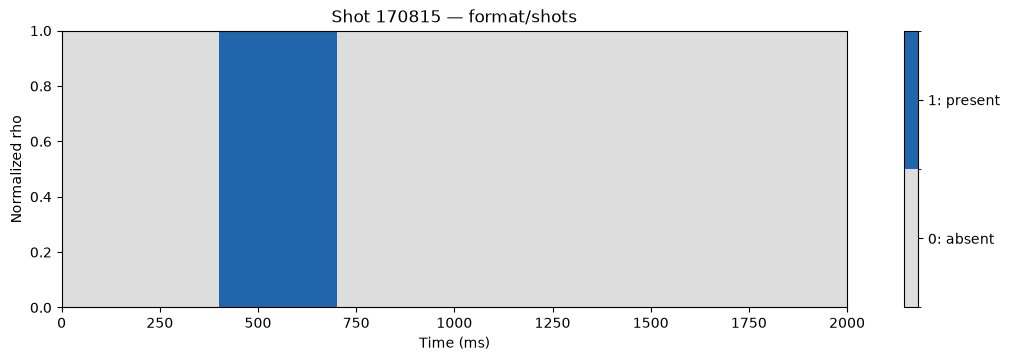

In [4]:
plot_shot(grid);

When extended labels are available, set `source` to `extend_<producer>/<shot-list>`.